In [1]:
#!python -m pip install --upgrade pip
#%pip install pandas matplotlib seaborn scikit-learn openpyxl tensorflow xgboost aif360
#%pip install "aif360[Reductions, inFairness]"

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint
from collections import Counter
from scipy.stats import chi2_contingency, fisher_exact
from sklearn.preprocessing import LabelEncoder

random_seed = 15

In [3]:
PATH = 'C:/Users/andre/Desktop/ProjectWork_AEQUITAS_AKKODIS/'
df = (
    pd.read_excel(PATH + 'data/Dataset_2.0_Akkodis.xlsx')
      .rename(columns=lambda c: c.lstrip().title())
)
df.head()

,Id,Candidate State,Age Range,Residence,Sex,Protected Category,Tag,Study Area,Study Title,Years Experience,...,Akkodis Headquarters,Current Ral,Expected Ral,Technical Skills,Standing/Position,Comunication,Maturity,Dynamism,Mobility,English
0,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,2.0,2.0,1.0,2.0,2.0,3.0,3.0
4,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
config = {}
config['drop_columns'] = [
    'Id', 'Tag', 'Year Of Insertion',
    'Year Of Recruitment', 'Recruitment Request', 'Assumption Headquarters',
    'Event_Type__Val', 'Linked_Search__Key', 'Job Description', 
    'Candidate Profile', 'Akkodis Headquarters', 'Standing/Position', 'Last Role', 'Study Area.1',
    'Years Experience.1']
config['drop_rows'] = {
    'Candidate State': ['First contact', 'Imported']
}
config['remap_rows'] = {
    'Protected Category': {
        'Article 18': 'Yes',
        'Article 1': 'Yes'
    },
    'Residence': {
        'ETHIOPIA': 'ETHIOPIA » (STATE) ~ (FOREIGN)',
        'SOUTH AFRICAN REPUBLIC': 'SOUTH AFRICAN REPUBLIC » (STATE) ~ (FOREIGN)',
        'USSR': 'USSR » (STATE) ~ (FOREIGN)',
        'YUGOSLAVIA': 'YUGOSLAVIA » (STATE) ~ (FOREIGN)'
    },
    'Study Area' : {
        'Automation/Mechatronics Engineering': 'Engineering',
        'computer engineering': 'Engineering',
        'chemical engineering': 'Engineering',
        'Legal': 'Law',
        'Mechanical engineering': 'Engineering',
        'Telecommunications Engineering': 'Engineering',
        'Economic - Statistics': 'Economic',
        'Psychology': 'Scientific Field',
        'Materials Science and Engineering': 'Engineering',
        'Other scientific subjects': 'Scientific Field',
        'Biomedical Engineering': 'Engineering',
        'electronic Engineering': 'Engineering',
        'Information Engineering': 'Engineering',
        'Aeronautical/Aerospace/Astronautics Engineering': 'Engineering',
        'Energy and Nuclear Engineering': 'Engineering',
        'Informatics': 'Informatics',
        'Management Engineering': 'Engineering',
        'Automotive Engineering': 'Engineering',
        'industrial engineering': 'Engineering',
        'Other': 'Other',
        'Surveyor': 'NO COLLEGE',
        'Civil/Civil and Environmental Engineering': 'Engineering',
        'Electrical Engineering': 'Engineering',
        'Scientific maturity': 'NO COLLEGE',
        'Chemist - Pharmaceutical': 'Medical Field',
        'Political-Social': 'Other Humanities Subjects',
        'Other humanities subjects': 'Other Humanities Subjects',
        'Geo-Biological': 'Scientific Field',
        'Linguistics': 'Linguistics',
        'Agriculture and veterinary': 'Scientific Field',
        'Literary': 'Other Humanities Subjects',
        'Humanistic high school diploma': 'NO COLLEGE',
        'Accounting': 'NO COLLEGE',
        'Communication Sciences': 'Other Humanities Subjects',
        'Safety Engineering': 'Engineering',
        'Architecture': 'Scientific Field',
        'Mathematics': 'Scientific Field',
        'construction Engineering': 'Engineering',
        'Petroleum Engineering': 'Engineering',
        'Naval Engineering': 'Engineering',
        'Artistic': 'NO COLLEGE',
        'Not Specified': 'Other',
        'Mathematical-physical modeling for engineering': 'Engineering',
        'Engineering for the environment and the territory': 'Engineering',
        'Medical': 'Medical Field',
        'Defense and Security': 'Other',
        'Physical education': 'Other',
        'Statistics': 'Scientific Field',
        'Educational/training sciences': 'Other Humanities Subjects'
    }
}
config['fill_nan_columns'] = {
    'Protected Category': 'Not a protected category',
    'Study Area': 'Not Specified',
    'Sector': 'Unemployed',
    'Job Family Hiring': 'Not Specified',
    'Job Title Hiring': 'Not Specified',
    'Event_Feedback': 'Not Specified',
    'Overall': 'Not Specified',
    'Minimum Ral': 'Not Specified',
    'Ral Maximum': 'Not Specified',
    'Study Level': 'Not Specified',
    'Current Ral': 'Not Specified',
    'Expected Ral': 'Not Specified',
    'Technical Skills': '%MEAN%',
    'Comunication': '%MEAN%',
    'Maturity': '%MEAN%',
    'Dynamism': '%MEAN%',
    'Mobility': '%MEAN%',
    'English': '%MEAN%'
}
config['drop_nan_columns_threshold'] = '100.0'
config['feature_remapping'] = {
    'Residence': {
        'lists': {
            'state':    {'src':'Residence', 'inc':['(STATE)','(COUNTRY)'], 'exc':['Not Specified'], 'split':(' » ', 0)                    },
            'city':     {'src':'Residence', 'exc':['(STATE)','(COUNTRY)','Not Specified'],          'split':(' » ', 0)                    },
            'province': {'src':'Residence', 'exc':['(STATE)','(COUNTRY)','Not Specified'],          'split':(' » ', 1), 'post':(' ~ ', 0) },
            'region':   {'src':'Residence', 'exc':['(STATE)','(COUNTRY)','Not Specified'],          'split':(' ~ ',-1)                    },
        },
        'fields': {
            'Residence City':     {'src':'Residence', 'list':'city',     'def':'Not Specified'},
            'Residence Province': {'src':'Residence', 'list':'province', 'def':'Not Specified'},
            'Residence Region':   {'src':'Residence', 'list':'region',   'def':'Not Specified'},
            'Residence State':    {'src':'Residence', 'list':'state',    'def':'ITALY'},
            'European Residence': {'src':'Residence State', 'in':'eu',    'y':'Yes','n':'No'},
            'Italian Residence':  {'src':'Residence State', 'eq':'ITALY', 'y':'Yes','n':'No'},
        },
        'eu': [
            'ALBANIA', 'AUSTRIA', 'BELARUS', 'BELGIUM', 'BULGARIA', 'CROATIA', 'CZECH REPUBLIC',
            'FRANCE', 'GERMANY', 'GREAT BRITAIN-NORTHERN IRELAND', 'GREECE', 'ITALY', 'LATVIA',
            'LITHUANIA', 'LUXEMBOURG', 'MALTA', 'MOLDOVA', 'MONACO', 'MONTENEGRO', 'NETHERLANDS',
            'NORWAY', 'POLAND', 'PORTUGAL', 'ROMANIA', 'RUSSIA', 'SAN MARINO', 'SERBIA', 'SLOVAKIA',
            'SLOVENIA', 'SPAIN', 'SWEDEN', 'SWITZERLAND', 'UKRAINE'
        ]
    }
}
config['status_positive_conditions'] = {
    'Candidate State': ['Hired', 'Economic proposal', 'QM'],
    'Event_Feedback': ['OK (live)', 'OK (waiting for departure)', 'OK (hired)']
}
config['categorical_columns'] = [
    'Candidate State', 'Event_Feedback', 
    'Residence City', 'Residence Province', 'Residence Region', 'Residence State', 'European Residence', 'Italian Residence',
    'Age Range', 'Sex',
    'Protected Category', 'Study Area', 'Study Title',
    'Years Experience', 'Sector', 'Job Family Hiring',
    'Job Title Hiring', 'Overall',
    'Minimum Ral', 'Ral Maximum', 'Study Level',
    'Current Ral', 'Expected Ral'
]

config['categorical_columns_custom_orders'] = {
    'Candidate State': ['Imported', 'First contact', 'In selection', 'QM', 'Vivier', 'Economic proposal', 'Hired'],
    'Age Range': ['< 20 years', '20 - 25 years', '26 - 30 years', '31 - 35 years', '36 - 40 years', '40 - 45 years', '> 45 years'],
    'Years Experience': [ '[0]', '[0-1]', '[1-3]', '[3-5]', '[5-7]', '[7-10]', '[+10]'],
    'Study Title': ['Middle school diploma', 'High school graduation', 'Professional qualification', 'Three-year degree', 'master\'s degree', 'Five-year degree', 'Doctorate'],
    'Study Level': ['Middle school diploma', 'High school graduation', 'Professional qualification', 'Three-year degree', 'master\'s degree', 'Five-year degree', 'Doctorate'],
    'Current Ral': ['Not available', 'Not Specified', '- 20 K', '20-22 K', '22-24 K', '24-26 K', '26-28 K', '28-30 K', '30-32 K', '32-34 K', '34-36 K', '36-38 K', '38-40 K', '40-42 K', '42-44 K', '44-46 K', '46-48 K', '48-50 K', '+ 50 K'],
    'Expected Ral': ['Not available', 'Not Specified', '- 20 K', '20-22 K', '22-24 K', '24-26 K', '26-28 K', '28-30 K', '30-32 K', '32-34 K', '34-36 K', '36-38 K', '38-40 K', '40-42 K', '42-44 K', '44-46 K', '46-48 K', '48-50 K', '+ 50 K'],
    'Ral Maximum': ['Not Avail.', 'Not Specified', '- 20K', '20K', '20-22K', '22-24K', '24-26K', '26-28K', '28-30K', '30-32K', '32-34K', '34-36K', '36-38K', '38-40K', '40-42K', '42-44K', '44-46K', '46-48K', '48-50k', '+50K'],
    'Minimum Ral': ['Not Avail.', 'Not Specified', '- 20K', '20K', '20-22K', '22-24K', '24-26K', '26-28K', '28-30K', '30-32K', '32-34K', '34-36K', '36-38K', '38-40K', '40-42K', '42-44K', '44-46K', '46-48K', '48-50K', '+50K'],
    'Overall' : ['~ 1 - Low', '1 - Low', '~ 2 - Medium', '2 - Medium', '~ 3 - High', '3 - High', '~ 4 - Top', '4 - Top']
}
config['visualize_columns'] = ['Candidate State', 'Age Range', 'Sex', 'Protected Category', 'Study Area', 'Study Title', 'Years Experience', 'Current Ral']
config['sensitive_columns'] = ['Sex', 'Age Range', 'Protected Category']
config['visualize_distributions_columns'] = ['Age Range']

## Data Preprocessing

### Clean Dataset

In [5]:
df = df.drop_duplicates(subset='Id', keep='last')
df.head()

,Id,Candidate State,Age Range,Residence,Sex,Protected Category,Tag,Study Area,Study Title,Years Experience,...,Akkodis Headquarters,Current Ral,Expected Ral,Technical Skills,Standing/Position,Comunication,Maturity,Dynamism,Mobility,English
5,71470,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,"AUTOSAR, CAN, C, C++, MATLAB/SIMULINK, VECTOR/...",Automation/Mechatronics Engineering,Five-year degree,[1-3],...,Modena,22-24 K,24-26 K,3.0,2.0,2.0,3.0,3.0,2.0,4.0
11,21020,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,"-, C, C++, DO178, LABVIEW, SOFTWARE DEVELOPMENT",computer engineering,Five-year degree,[7-10],...,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,27054,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,PROCESS ENG.,chemical engineering,Five-year degree,[3-5],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,27966,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,"CISCO, NOC DAS SUPPORT, SOC",Legal,Five-year degree,[7-10],...,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,48399,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,"CALIBRATION, CAN, DYANALIZER, GT POWER, HIL, M...",Mechanical engineering,Five-year degree,[3-5],...,NaN,NaN,24-26 K,3.0,2.0,2.0,2.0,3.0,1.0,1.0


In [6]:
df = df.drop(columns=config['drop_columns'])
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Automation/Mechatronics Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,computer engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,chemical engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Legal,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Mechanical engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [7]:
for col, remove_list in config['drop_rows'].items():
    df = df[~df[col].isin(remove_list)]
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Automation/Mechatronics Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,computer engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,chemical engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Legal,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Mechanical engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [8]:
for col, mapping in config['remap_rows'].items():
    df[col] = df[col].replace(mapping)
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,Engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,Engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Law,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [9]:
for feature in df.columns:
    print(f'Feature: {feature} -- {list(df[feature].unique())}')

Feature: Candidate State -- ['Hired', 'Vivier', 'QM', 'In selection', 'Economic proposal']
Feature: Age Range -- ['31 - 35 years', '40 - 45 years', '36 - 40 years', '> 45 years', '26 - 30 years', '< 20 years', '20 - 25 years']
Feature: Residence -- ['TURIN » Turin ~ Piedmont', 'CONVERSANO » Bari ~ Puglia', 'CASERTA » Caserta ~ Campania', 'SESTO SAN GIOVANNI » Milan ~ Lombardy', 'MAZARA DEL VALLO » Trapani ~ Sicily', 'MILAN » Milan ~ Lombardy', 'CHIERI » Turin ~ Piedmont', 'MARINE » Rome ~ Lazio', 'FANO » Pesaro-Urbino ~ Marche', 'CAPANNOLI » Pisa ~ Tuscany', 'LANCIANO » Chieti ~ Abruzzo', 'LIVORNO » Livorno ~ Tuscany', 'ASCOLI SATRIANO » Foggia ~ Puglia', 'EMPOLI » Florence ~ Tuscany', 'VITERBO » Viterbo ~ Lazio', 'SAN GIULIANO TERME » Pisa ~ Tuscany', 'SUPERSANO » Lecce ~ Puglia', 'MAZZARINO » Caltanissetta ~ Sicily', 'CAPANNORI » Lucca ~ Tuscany', 'MASSA » Massa-Carrara ~ Tuscany', 'FLORENCE » Florence ~ Tuscany', 'GERMANY » (STATE) ~ (OVERSEAS)', 'BOLOGNA » Bologna ~ Emilia Romagna'

### Handle the NANs

In [10]:
print(f'Columns that contain NaN values:\n {df.columns[df.isnull().any()].tolist()}')

for col in df.columns[df.isnull().any()].tolist():
  print(f'{col} values: {df[col].unique()} \n') # Analyze each NaN containing feature first to determine the default fill value

Columns that contain NaN values:
 ['Protected Category', 'Sector', 'Job Family Hiring', 'Job Title Hiring', 'Event_Feedback', 'Overall', 'Minimum Ral', 'Ral Maximum', 'Study Level', 'Current Ral', 'Expected Ral', 'Technical Skills', 'Comunication', 'Maturity', 'Dynamism', 'Mobility', 'English']
Protected Category values: [nan 'Yes'] 

Sector values: ['Automotive' 'Aeronautics' 'Consulting' 'Telecom' 'Others' 'Space'
 'Life sciences' nan 'Railway' 'Defence' 'Naval'
 'Services and Information Systems' 'Machining - Heavy Industry' 'Energy'
 'Oil and Gas'] 

Job Family Hiring values: ['Engineering' nan 'Support' 'Tech Consulting & Solutions'
 'Business & Sales' 'Enabling Function' 'Business Management & Sales'
 'Talent Acquisition'] 

Job Title Hiring values: ['Consultant' nan 'Support Advanced' 'Qualified Consultant' 'Team Leader'
 'Advanced Consultant' 'Business Manager' 'Junior Consultant' '???'
 'Junior Business Manager' 'Support' 'Senior Consultant'
 'Business Unit Director' 'Pharmace

In [11]:
unuseful_columns = []
for col in df.columns:
  null_count = df[col].isna().sum() / df.shape[0]
  if null_count > float(config['drop_nan_columns_threshold']):
    unuseful_columns.append(col)
  
df = df.drop(columns=unuseful_columns)
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,NaN,Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,NaN,Engineering,Five-year degree,[7-10],Aeronautics,NaN,...,NaN,NaN,24-26 K,26-28 K,NaN,NaN,NaN,NaN,NaN,NaN
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,NaN,Engineering,Five-year degree,[3-5],Consulting,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,NaN,Law,Five-year degree,[7-10],Telecom,NaN,...,NaN,NaN,20-22 K,20-22 K,NaN,NaN,NaN,NaN,NaN,NaN
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,NaN,Engineering,Five-year degree,[3-5],Automotive,NaN,...,NaN,NaN,NaN,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [12]:
for col, filler in config['fill_nan_columns'].items():
    if filler == '%MEAN%':
        media = round(df[col].mean())
        df[col].fillna(media, inplace=True)
    else:
        df[col].fillna(filler, inplace=True)
df.head()

,Candidate State,Age Range,Residence,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,...,Ral Maximum,Study Level,Current Ral,Expected Ral,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English
5,Hired,31 - 35 years,TURIN » Turin ~ Piedmont,Male,Not a protected category,Engineering,Five-year degree,[1-3],Automotive,Engineering,...,30-32K,Five-year degree,22-24 K,24-26 K,3.0,2.0,3.0,3.0,2.0,4.0
11,Vivier,40 - 45 years,CONVERSANO » Bari ~ Puglia,Female,Not a protected category,Engineering,Five-year degree,[7-10],Aeronautics,Not Specified,...,Not Specified,Not Specified,24-26 K,26-28 K,2.0,2.0,2.0,2.0,2.0,3.0
13,QM,36 - 40 years,CASERTA » Caserta ~ Campania,Male,Not a protected category,Engineering,Five-year degree,[3-5],Consulting,Not Specified,...,Not Specified,Not Specified,Not Specified,Not Specified,2.0,2.0,2.0,2.0,2.0,3.0
17,QM,> 45 years,SESTO SAN GIOVANNI » Milan ~ Lombardy,Male,Not a protected category,Law,Five-year degree,[7-10],Telecom,Not Specified,...,Not Specified,Not Specified,20-22 K,20-22 K,2.0,2.0,2.0,2.0,2.0,3.0
25,In selection,31 - 35 years,MAZARA DEL VALLO » Trapani ~ Sicily,Male,Not a protected category,Engineering,Five-year degree,[3-5],Automotive,Not Specified,...,Not Specified,Not Specified,Not Specified,24-26 K,3.0,2.0,2.0,3.0,1.0,1.0


In [13]:
print(f'There are {df.isnull().sum().sum()} NANs')

There are 0 NANs


### Features Reformatting

In [14]:
print(df['Residence'].unique())

['TURIN » Turin ~ Piedmont' 'CONVERSANO » Bari ~ Puglia'
 'CASERTA » Caserta ~ Campania' 'SESTO SAN GIOVANNI » Milan ~ Lombardy'
 'MAZARA DEL VALLO » Trapani ~ Sicily' 'MILAN » Milan ~ Lombardy'
 'CHIERI » Turin ~ Piedmont' 'MARINE » Rome ~ Lazio'
 'FANO » Pesaro-Urbino ~ Marche' 'CAPANNOLI » Pisa ~ Tuscany'
 'LANCIANO » Chieti ~ Abruzzo' 'LIVORNO » Livorno ~ Tuscany'
 'ASCOLI SATRIANO » Foggia ~ Puglia' 'EMPOLI » Florence ~ Tuscany'
 'VITERBO » Viterbo ~ Lazio' 'SAN GIULIANO TERME » Pisa ~ Tuscany'
 'SUPERSANO » Lecce ~ Puglia' 'MAZZARINO » Caltanissetta ~ Sicily'
 'CAPANNORI » Lucca ~ Tuscany' 'MASSA » Massa-Carrara ~ Tuscany'
 'FLORENCE » Florence ~ Tuscany' 'GERMANY » (STATE) ~ (OVERSEAS)'
 'BOLOGNA » Bologna ~ Emilia Romagna' 'PISA » Pisa ~ Tuscany'
 'CARRARA » Massa-Carrara ~ Tuscany' 'PONTEDERA » Pisa ~ Tuscany'
 'MODENA » Modena ~ Emilia Romagna' 'TARANTO » Taranto ~ Puglia'
 'CECINA » Livorno ~ Tuscany' 'MARSALA » Trapani ~ Sicily'
 'SEZZE » Latina ~ Lazio' 'MONZA » Monza-Bria

In [15]:
def gen_lists(df, specs):
    out = {}
    for name, p in specs.items():
        base = out.get(p['src'], df[p['src']].dropna().astype(str).unique())
        # filtra inc/exc
        items = [
            x for x in base
            if not any(exc in x for exc in p.get('exc', []))
               and (any(inc in x for inc in p.get('inc', [])) if 'inc' in p else True)
        ]
        # split / post-split
        for key in ('split', 'post'):
            if key in p:
                sep, idx = p[key]
                items = [x.split(sep)[idx] if sep in x else x for x in items]
        out[name] = sorted(set(items))
    return out

def apply_field(val, p, lists, feature_cfg):
    # pattern‐match su lista
    if 'list' in p:
        return next((x for x in lists[p['list']] if x in str(val)), p['def'])
    # appartenenza in lista
    if 'in' in p:
        return p['y'] if val in feature_cfg[p['in']] else p['n']
    # confronto esatto
    if 'eq' in p:
        return p['y'] if str(val) == p['eq'] else p['n']

# Applica per ogni feature definita ———
for feature, feat_cfg in config['feature_remapping'].items():
    # Genera le liste specifiche
    lists = gen_lists(df, feat_cfg['lists'])
    # Mappa ogni campo
    for col_name, col_cfg in feat_cfg['fields'].items():
        df[col_name] = df[col_cfg['src']].apply(lambda v, cfg=col_cfg: apply_field(v, cfg, lists, feat_cfg))
    # Elimina le colonne originali
    df = df.drop(columns=feature, errors='ignore')
df.head()


,Candidate State,Age Range,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,Job Title Hiring,...,Maturity,Dynamism,Mobility,English,Residence City,Residence Province,Residence Region,Residence State,European Residence,Italian Residence
5,Hired,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[1-3],Automotive,Engineering,Consultant,...,3.0,3.0,2.0,4.0,TURIN,Turin,Piedmont,ITALY,Yes,Yes
11,Vivier,40 - 45 years,Female,Not a protected category,Engineering,Five-year degree,[7-10],Aeronautics,Not Specified,Not Specified,...,2.0,2.0,2.0,3.0,CONVERSANO,Bari,Puglia,ITALY,Yes,Yes
13,QM,36 - 40 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Consulting,Not Specified,Not Specified,...,2.0,2.0,2.0,3.0,CASERTA,Caserta,Campania,ITALY,Yes,Yes
17,QM,> 45 years,Male,Not a protected category,Law,Five-year degree,[7-10],Telecom,Not Specified,Not Specified,...,2.0,2.0,2.0,3.0,SESTO SAN GIOVANNI,Milan,Lombardy,ITALY,Yes,Yes
25,In selection,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Automotive,Not Specified,Not Specified,...,2.0,3.0,1.0,1.0,ARA,Trapani,Sicily,ITALY,Yes,Yes


In [16]:
for feature in df.columns:
    print(f'Feature: {feature} -- {list(df[feature].unique())}')

Feature: Candidate State -- ['Hired', 'Vivier', 'QM', 'In selection', 'Economic proposal']
Feature: Age Range -- ['31 - 35 years', '40 - 45 years', '36 - 40 years', '> 45 years', '26 - 30 years', '< 20 years', '20 - 25 years']
Feature: Sex -- ['Male', 'Female']
Feature: Protected Category -- ['Not a protected category', 'Yes']
Feature: Study Area -- ['Engineering', 'Law', 'Economic', 'Scientific Field', 'Informatics', 'Other', 'NO COLLEGE', 'Medical Field', 'Other Humanities Subjects', 'Linguistics']
Feature: Study Title -- ['Five-year degree', 'Doctorate', 'High school graduation', 'Three-year degree', "master's degree", 'Middle school diploma', 'Professional qualification']
Feature: Years Experience -- ['[1-3]', '[7-10]', '[3-5]', '[5-7]', '[+10]', '[0]', '[0-1]']
Feature: Sector -- ['Automotive', 'Aeronautics', 'Consulting', 'Telecom', 'Others', 'Space', 'Life sciences', 'Unemployed', 'Railway', 'Defence', 'Naval', 'Services and Information Systems', 'Machining - Heavy Industry', 'E

### Target Column

In [17]:
config['categorical_columns'].append('Status')

mask = np.zeros(len(df), dtype=bool)
for col, valid_values in config['status_positive_conditions'].items():
    mask |= df[col].isin(valid_values)
df['Status'] = np.where(mask, 'Positive', 'Negative')
df.head()

,Candidate State,Age Range,Sex,Protected Category,Study Area,Study Title,Years Experience,Sector,Job Family Hiring,Job Title Hiring,...,Dynamism,Mobility,English,Residence City,Residence Province,Residence Region,Residence State,European Residence,Italian Residence,Status
5,Hired,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[1-3],Automotive,Engineering,Consultant,...,3.0,2.0,4.0,TURIN,Turin,Piedmont,ITALY,Yes,Yes,Positive
11,Vivier,40 - 45 years,Female,Not a protected category,Engineering,Five-year degree,[7-10],Aeronautics,Not Specified,Not Specified,...,2.0,2.0,3.0,CONVERSANO,Bari,Puglia,ITALY,Yes,Yes,Negative
13,QM,36 - 40 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Consulting,Not Specified,Not Specified,...,2.0,2.0,3.0,CASERTA,Caserta,Campania,ITALY,Yes,Yes,Positive
17,QM,> 45 years,Male,Not a protected category,Law,Five-year degree,[7-10],Telecom,Not Specified,Not Specified,...,2.0,2.0,3.0,SESTO SAN GIOVANNI,Milan,Lombardy,ITALY,Yes,Yes,Positive
25,In selection,31 - 35 years,Male,Not a protected category,Engineering,Five-year degree,[3-5],Automotive,Not Specified,Not Specified,...,3.0,1.0,1.0,ARA,Trapani,Sicily,ITALY,Yes,Yes,Negative


In [18]:
for feature in df.columns:
    print(f'Feature: {feature} -- {list(df[feature].unique())}')

Feature: Candidate State -- ['Hired', 'Vivier', 'QM', 'In selection', 'Economic proposal']
Feature: Age Range -- ['31 - 35 years', '40 - 45 years', '36 - 40 years', '> 45 years', '26 - 30 years', '< 20 years', '20 - 25 years']
Feature: Sex -- ['Male', 'Female']
Feature: Protected Category -- ['Not a protected category', 'Yes']
Feature: Study Area -- ['Engineering', 'Law', 'Economic', 'Scientific Field', 'Informatics', 'Other', 'NO COLLEGE', 'Medical Field', 'Other Humanities Subjects', 'Linguistics']
Feature: Study Title -- ['Five-year degree', 'Doctorate', 'High school graduation', 'Three-year degree', "master's degree", 'Middle school diploma', 'Professional qualification']
Feature: Years Experience -- ['[1-3]', '[7-10]', '[3-5]', '[5-7]', '[+10]', '[0]', '[0-1]']
Feature: Sector -- ['Automotive', 'Aeronautics', 'Consulting', 'Telecom', 'Others', 'Space', 'Life sciences', 'Unemployed', 'Railway', 'Defence', 'Naval', 'Services and Information Systems', 'Machining - Heavy Industry', 'E

### Categorical columns

In [19]:
encoding_mappings = {}

for col in config['categorical_columns']:
    if col in config['categorical_columns_custom_orders']:
        df[f"{col}_encoded"] = pd.Categorical(df[col], categories=config['categorical_columns_custom_orders'][col], ordered=True).codes
        encoding_mappings[col] = {cat: i for i, cat in enumerate(config['categorical_columns_custom_orders'][col])}
    else:
        encoder = LabelEncoder()
        df[f"{col}_encoded"] = encoder.fit_transform(df[col].astype(str))
        encoding_mappings[col] = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))

df = df.drop(columns=config['categorical_columns'])
df.head()

,Technical Skills,Comunication,Maturity,Dynamism,Mobility,English,Candidate State_encoded,Event_Feedback_encoded,Residence City_encoded,Residence Province_encoded,...,Sector_encoded,Job Family Hiring_encoded,Job Title Hiring_encoded,Overall_encoded,Minimum Ral_encoded,Ral Maximum_encoded,Study Level_encoded,Current Ral_encoded,Expected Ral_encoded,Status_encoded
5,3.0,2.0,3.0,3.0,2.0,4.0,6,11,689,102,...,1,3,5,4,7,9,5,4,5,1
11,2.0,2.0,2.0,2.0,2.0,3.0,4,10,218,8,...,0,4,8,-1,1,1,-1,5,6,0
13,2.0,2.0,2.0,2.0,2.0,3.0,3,9,157,22,...,2,4,8,-1,1,1,-1,1,1,1
17,2.0,2.0,2.0,2.0,2.0,3.0,3,11,636,57,...,13,4,8,-1,1,1,-1,3,3,1
25,3.0,2.0,2.0,3.0,1.0,1.0,-1,11,39,98,...,1,4,8,2,1,1,-1,1,5,0


In [20]:
for feature in df.columns:
    print(f'Feature: {feature} -- {list(df[feature].unique())}')

Feature: Technical Skills -- [3.0, 2.0, 1.0, 4.0]
Feature: Comunication -- [2.0, 3.0, 1.0, 4.0]
Feature: Maturity -- [3.0, 2.0, 1.0, 4.0]
Feature: Dynamism -- [3.0, 2.0, 1.0, 4.0]
Feature: Mobility -- [2.0, 1.0, 3.0, 4.0]
Feature: English -- [4.0, 3.0, 1.0, 2.0]
Feature: Candidate State_encoded -- [6, 4, 3, -1, 5]
Feature: Event_Feedback_encoded -- [11, 10, 9, 15, 5, 13, 3, 2, 7, 12, 6, 8, 14, 4, 1, 0]
Feature: Residence City_encoded -- [689, 218, 157, 636, 39, 394, 194, 43, 253, 136, 335, 351, 50, 247, 731, 587, 658, 137, 383, 266, 628, 93, 501, 516, 403, 179, 377, 639, 429, 499, 52, 696, 255, 598, 241, 507, 614, 195, 453, 254, 309, 290, 58, 331, 399, 226, 727, 15, 397, 422, 528, 459, 684, 582, 328, 642, 653, 243, 616, 477, 540, 14, 17, 238, 297, 70, 267, 86, 27, 337, 219, 34, 176, 704, 533, 312, 566, 600, 502, 6, 400, 554, 552, 411, 196, 656, 412, 647, 551, 127, 463, 406, 447, 341, 462, 87, 227, 125, 323, 543, 456, 445, 214, 450, 504, 736, 662, 82, 584, 295, 88, 79, 493, 479, 690, 40

### Visualize Data

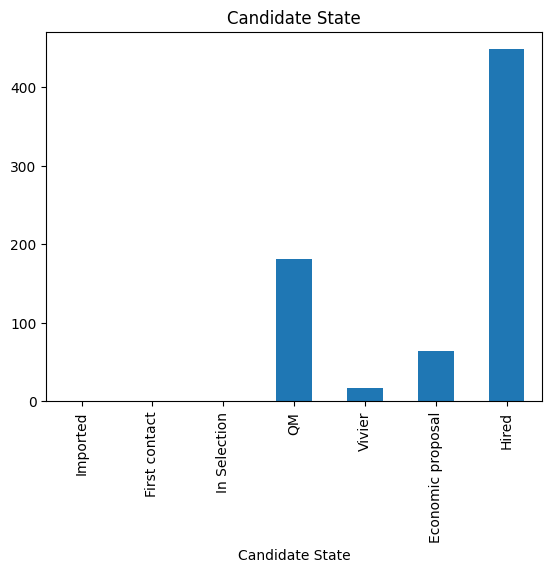

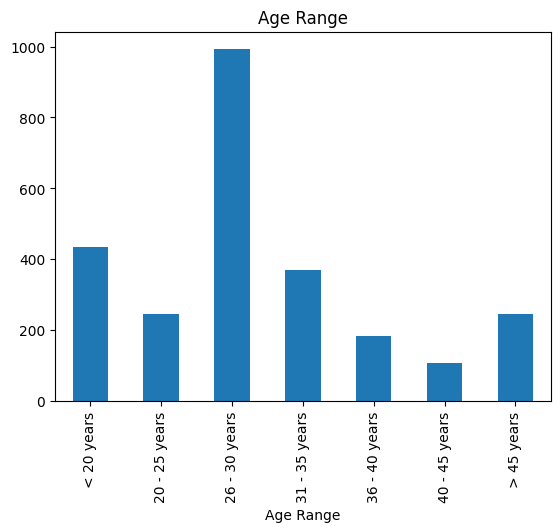

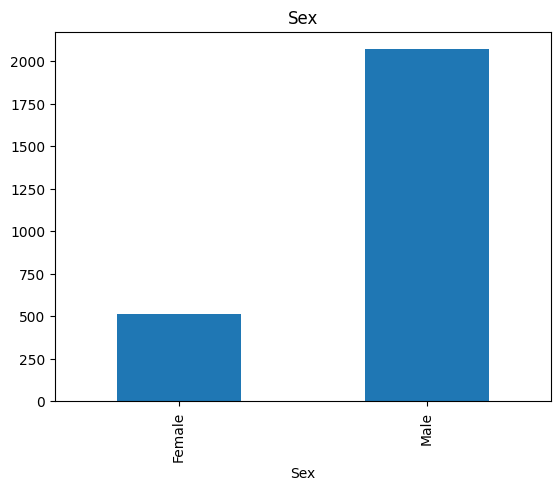

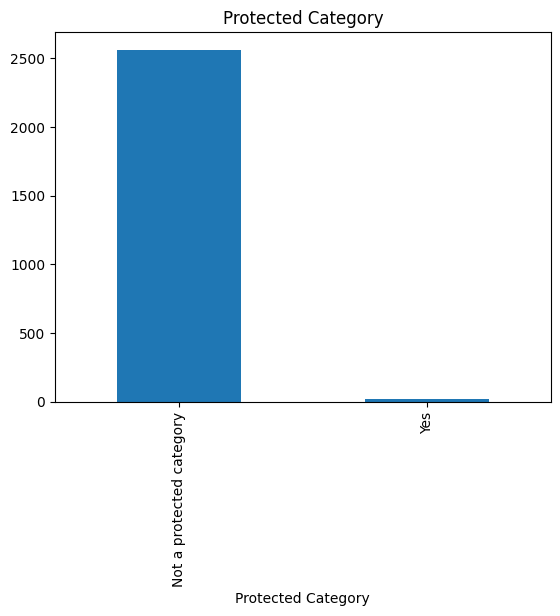

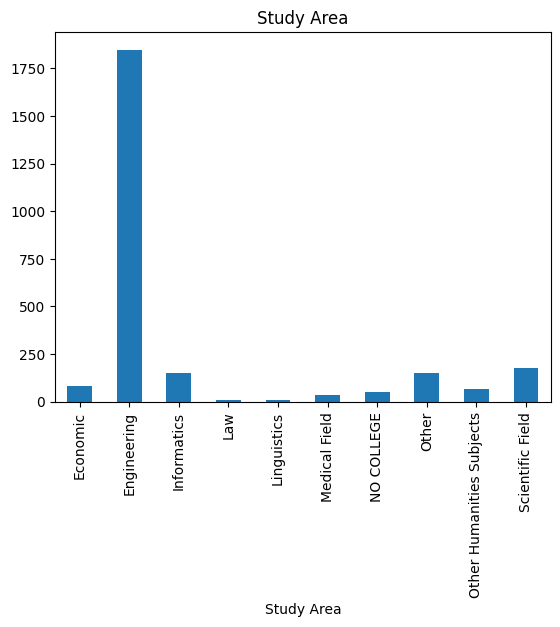

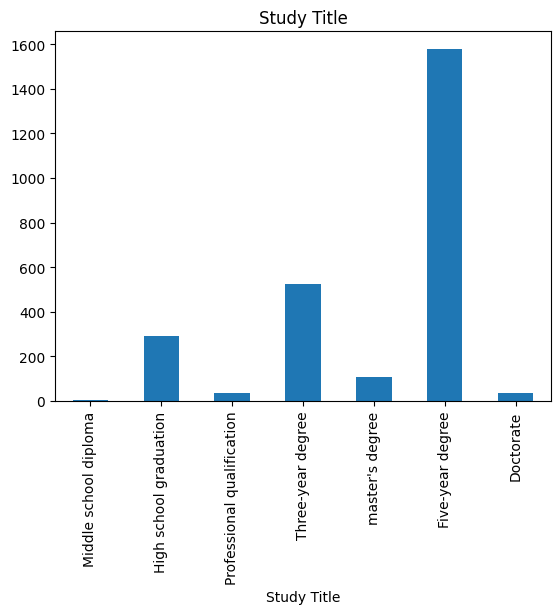

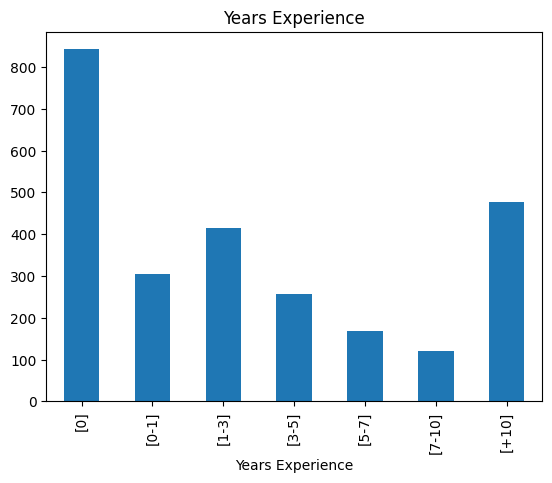

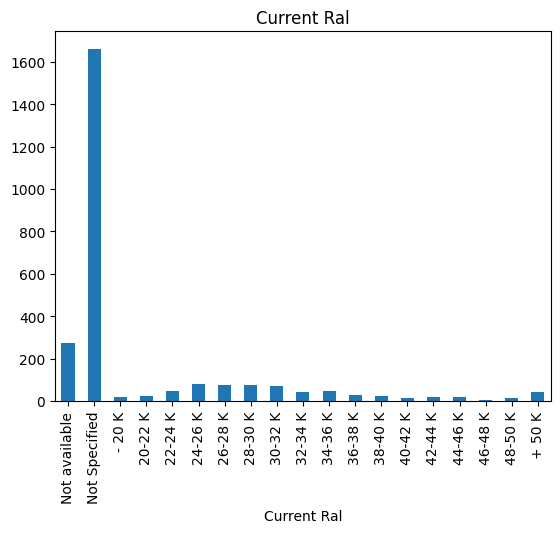

In [21]:
for lookup in config['visualize_columns']:
    mapping = {v: k for k, v in encoding_mappings[lookup].items()}
    codes = sorted(mapping.keys())
    distrib = Counter(df[f"{lookup}_encoded"])
    labels = [mapping[c] for c in codes]
    counts = [distrib[c] for c in codes]
    distrib_df = pd.DataFrame({lookup: labels, 'Count': counts})
    distrib_df.head(20).plot(x=lookup, y='Count', kind='bar', legend=False)
    plt.title(lookup)

#### Correlation Matrix

<Axes: >

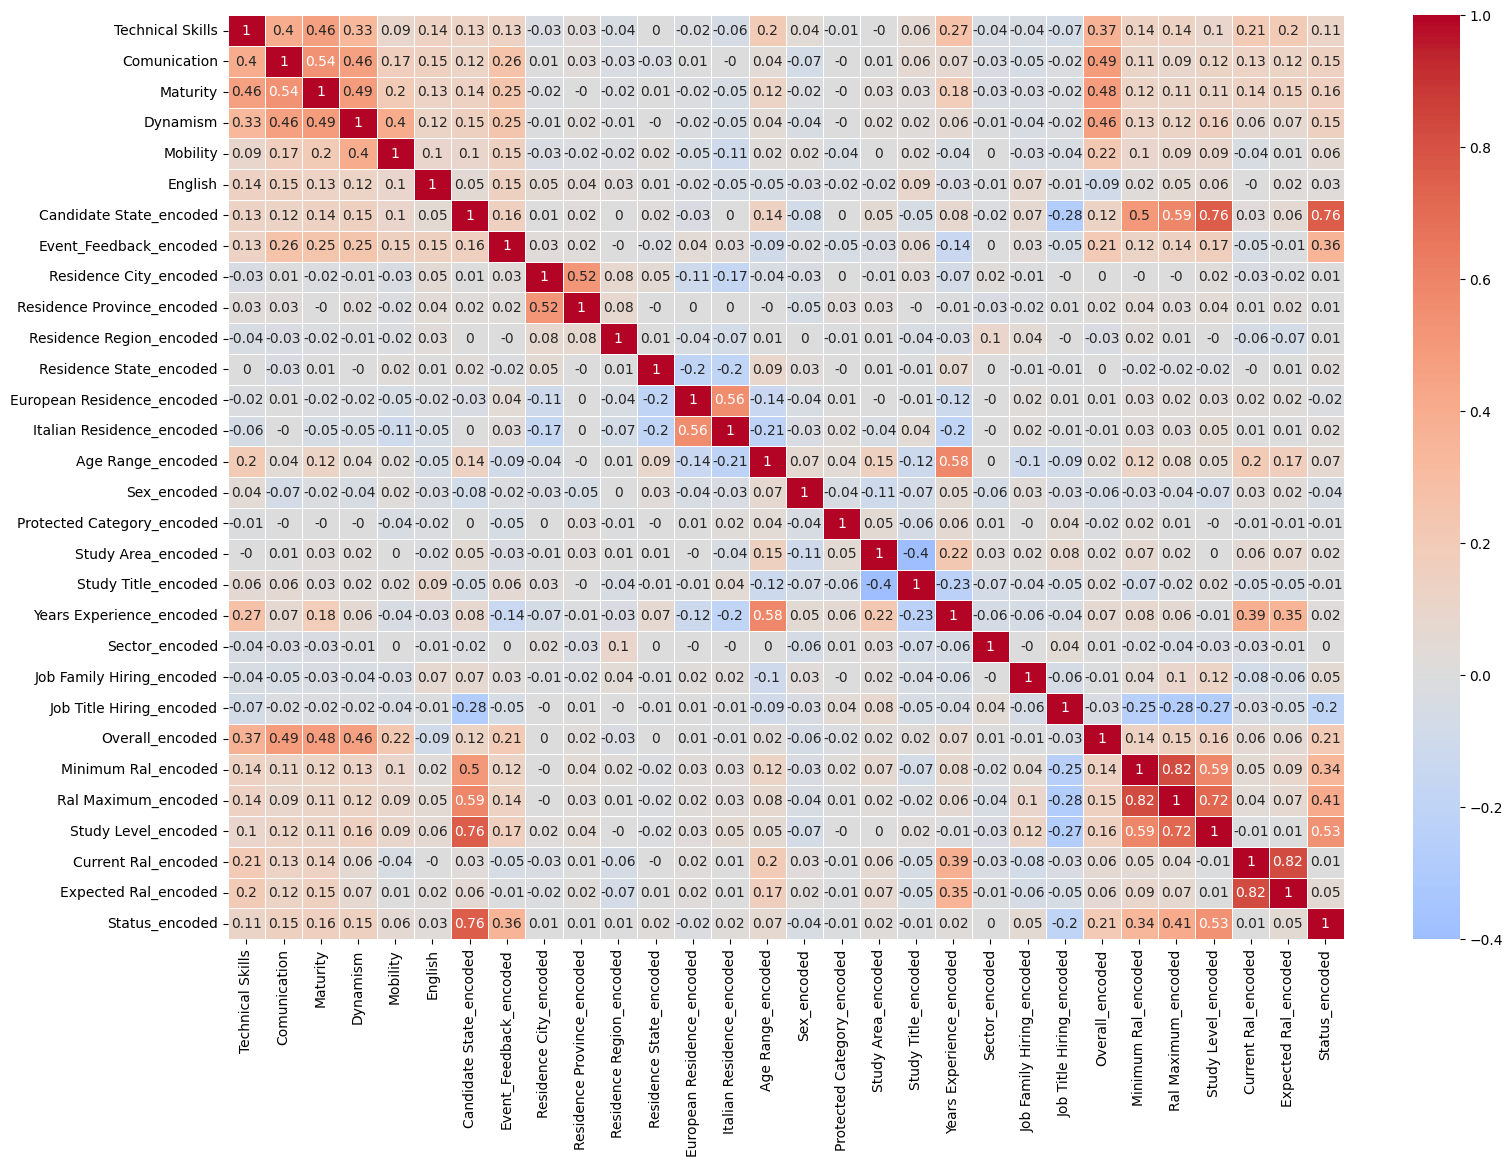

In [22]:
plt.figure(figsize=(18, 12))
sns.heatmap(df.corr().round(2), annot=True, cmap='coolwarm', center=0, linewidths=.5)

### Visualize Percentage of Positive Status inside each class

In [23]:
pprint(encoding_mappings, width=120, compact=False)

{'Age Range': {'20 - 25 years': 1,
               '26 - 30 years': 2,
               '31 - 35 years': 3,
               '36 - 40 years': 4,
               '40 - 45 years': 5,
               '< 20 years': 0,
               '> 45 years': 6},
 'Candidate State': {'Economic proposal': 5,
                     'First contact': 1,
                     'Hired': 6,
                     'Imported': 0,
                     'In Selection': 2,
                     'QM': 3,
                     'Vivier': 4},
 'Current Ral': {'+ 50 K': 18,
                 '- 20 K': 2,
                 '20-22 K': 3,
                 '22-24 K': 4,
                 '24-26 K': 5,
                 '26-28 K': 6,
                 '28-30 K': 7,
                 '30-32 K': 8,
                 '32-34 K': 9,
                 '34-36 K': 10,
                 '36-38 K': 11,
                 '38-40 K': 12,
                 '40-42 K': 13,
                 '42-44 K': 14,
                 '44-46 K': 15,
                 '46-48 K': 16

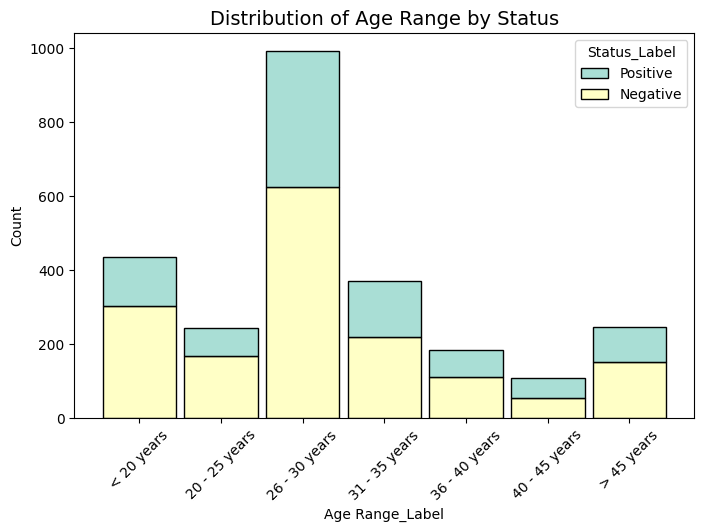

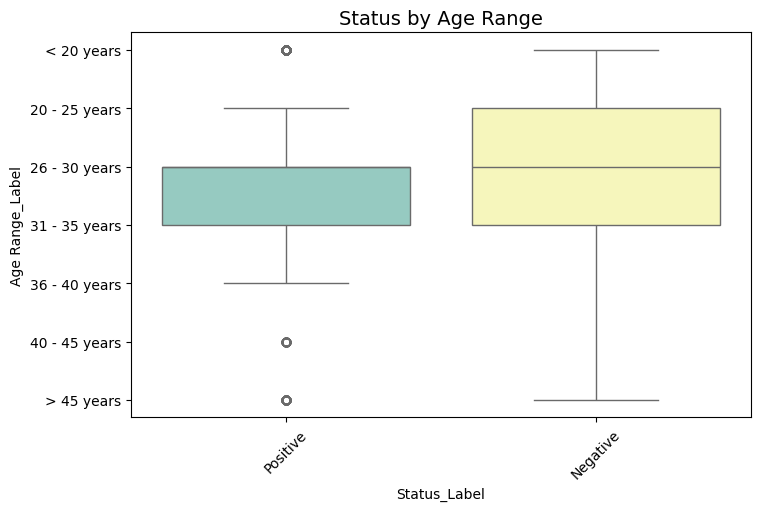

In [24]:
for snstv_col in config['visualize_distributions_columns']:
    sensitive_map = {v: k for k, v in encoding_mappings[snstv_col].items()}
    status_map = {v: k for k, v in encoding_mappings['Status'].items()}
    ordered_sensitive_map = [k for k, v in sorted(encoding_mappings[snstv_col].items(), key=lambda x: x[1])]
    # Assign the correct label column for the sensitive attribute
    plot_df = df.assign(
        **{f"{snstv_col}_Label": df[f"{snstv_col}_encoded"].map(sensitive_map)},
        Status_Label=df['Status_encoded'].map(status_map)
    )
    plot_df[f"{snstv_col}_Label"] = pd.Categorical(plot_df[f"{snstv_col}_Label"], categories=ordered_sensitive_map, ordered=True)

    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=plot_df,
        x=f"{snstv_col}_Label",
        hue='Status_Label',
        multiple='stack',
        palette='Set3',
        shrink=0.9
    )
    plt.title(f"Distribution of {snstv_col} by Status", fontsize=14)
    plt.xticks(rotation=45)

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=plot_df,
        x='Status_Label',
        y=f"{snstv_col}_Label",
        palette='Set3',
        hue='Status_Label',
    )
    plt.title(f"Status by {snstv_col}", fontsize=14)
    plt.xticks(rotation=45)


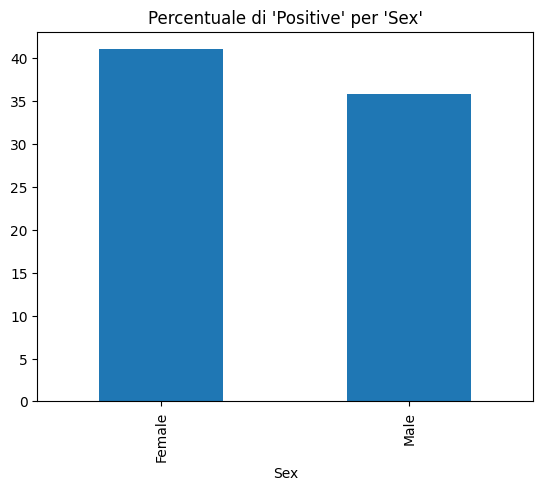

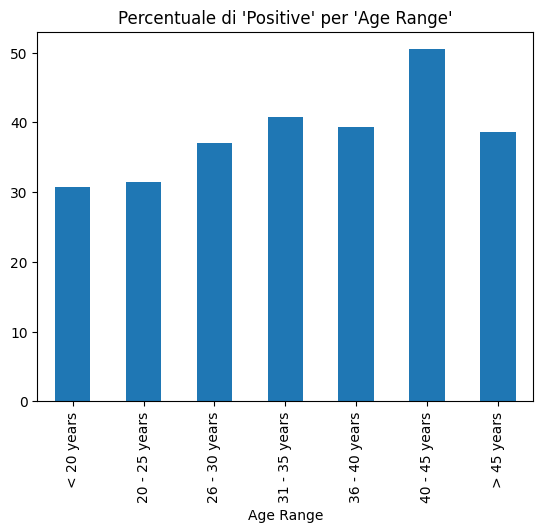

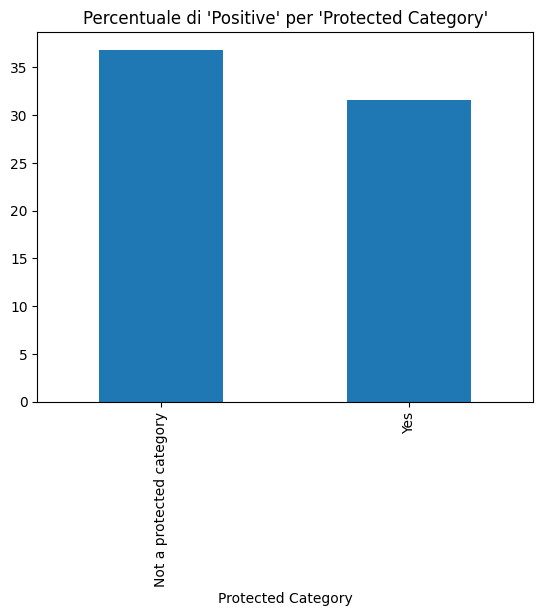

In [25]:
status_map = {v: k for k, v in encoding_mappings['Status'].items()}
for feature in config['sensitive_columns']:
    cat_map = {v: k for k, v in encoding_mappings[feature].items()}
    percentage = df.groupby(f"{feature}_encoded")['Status_encoded'].mean().mul(100).round(2)
    labels = [cat_map[code] for code in percentage.index]
    distrib_df = pd.DataFrame({feature: labels, 'Percentuale_' + status_map[1]: percentage.values})
    distrib_df.plot(x=feature, y=f"Percentuale_{status_map[1]}", kind='bar', legend=False)
    plt.title(f"Percentuale di '{status_map[1]}' per '{feature}'")

## Save to File

In [26]:
df.to_excel(PATH + 'data/Dataset_Preprocessed.xlsx', index=False)

## Chi-squared Tests

In [27]:
for col in config['sensitive_columns']:
    encoded_col = f"{col}_encoded"
    mapping = {v: k for k, v in encoding_mappings[col].items()}
    status_mapping = {v: k for k, v in encoding_mappings['Status'].items()}
    contingency = pd.crosstab(df[encoded_col], df['Status_encoded'])
    contingency.index = contingency.index.map(mapping)
    contingency.columns = [status_mapping[c] for c in contingency.columns]

    chi2, p, dof, expected = chi2_contingency(contingency, correction=False)
    test_name = 'Chi-squared'
    # Se 2x2 e attese <5 → Fisher’s exact
    if contingency.shape == (2, 2) and (expected < 5).any():
        _, p = fisher_exact(contingency)
        test_name = "Fisher's exact"

    n = contingency.values.sum()
    k = min(contingency.shape)
    cramer_v = np.sqrt(chi2 / (n * (k - 1)))

    print(f"--- {col} ---")
    print("Expected frequencies:")
    print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))
    print()
    print(f"{test_name}: χ² = {chi2:.2f}, p = {p:.3f}, dof = {dof}, Cramér’s V = {cramer_v:.3f}")
    print("Conclusion: Significant association between two variables (Dependent)" if p < 0.05 else "Conclusion: No significant association between two variables (Independent)")
    print()


--- Sex ---
Expected frequencies:
                Negative    Positive
Sex_encoded                         
Female        323.420604  188.579396
Male         1307.579396  762.420604

Chi-squared: χ² = 4.80, p = 0.028, dof = 1, Cramér’s V = 0.043
Conclusion: Significant association between two variables (Dependent)

--- Age Range ---
Expected frequencies:
                     Negative    Positive
Age Range_encoded                        
< 20 years         275.412858  160.587142
20 - 25 years      154.761813   90.238187
26 - 30 years      626.627421  365.372579
31 - 35 years      234.353602  136.646398
36 - 40 years      115.597599   67.402401
40 - 45 years       68.853215   40.146785
> 45 years         155.393493   90.606507

Chi-squared: χ² = 21.97, p = 0.001, dof = 6, Cramér’s V = 0.092
Conclusion: Significant association between two variables (Dependent)

--- Protected Category ---
Expected frequencies:
                               Negative    Positive
Protected Category_encoded  